
Train Skip-gram with Negative Sampling on a Wikipedia article,
then evaluate the embedding model with intrinsic tests and custom test sets.

Requirements:
    pip install requests beautifulsoup4 nltk gensim scikit-learn scipy

Optional:
    python -m nltk.downloader punkt stopwords

In [95]:
import re
import json
import random
from typing import List, Tuple, Dict

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [96]:
# Paste the Wikipedia link you want to use here. 
# The article should be reasonably long (at least a few thousand words) for good results.
WIKI_URL = "https://en.wikipedia.org/wiki/Iloilo_City"
RANDOM_SEED = 42

In [97]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

In [98]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-Gundam-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [99]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for token in tokens:
            token = token.strip("-")
            if not token:
                continue
            if token.isdigit():
                continue
            if len(token) < 2:
                continue
            cleaned.append(token)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed


In [100]:
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

In [101]:
def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100, # What happens if we change this? Try 50, 200, 300 and see how it affects results.
        window=10,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

In [102]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index


def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

In [103]:
def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }

In [104]:
def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

In [105]:
def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

In [ ]:
def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences)


    print("model: ", model)

    print("\nVocabulary size learned:", len(model.wv))

    probe_words = [
        "iloilo", "city", "philippines", "panay", "visayas",
        "guimaras", "province", "island", "river", "festival"
    ]
    print_top_neighbors(model, probe_words, topn=8)

    # Domain-specific relatedness test set
    # Higher score means should be more semantically related
    relatedness_test = [
        # These scores in the pairs are just examples, 
        # you are the ones providing it. 
        # You can adjust them based on your understanding of 
        # the article and what you expect the model to learn.
        
        ("iloilo", "city", 0.95),
        ("iloilo", "philippines", 0.80),
        ("iloilo", "panay", 0.85),
        ("iloilo", "visayas", 0.80),
        ("iloilo", "province", 0.75),
        ("festival", "dinagyang", 0.90),
        ("jaro", "district", 0.85),
        ("molo", "district", 0.85),
        ("river", "port", 0.60),
        ("festival", "river", 0.10),
        ("port", "festival", 0.10),
        ("province", "river", 0.20),
    ]

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    # Small analogy-style test set
    # These are intentionally tiny and corpus-dependent 
    # because a single article is a small dataset.
    # Change this based on what you find in the article and 
    # what words are present in the model.
    analogy_test = [
        ("iloilo", "city", "panay", "island"),
        ("jaro", "district", "molo", "district"),
        ("philippines", "country", "iloilo", "city"),
    ]

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Example direct similarity checks
    print("\n=== Direct Similarity Checks ===")
    # Change these pairs based on what you expect to be 
    # related/unrelated in the article and what words are in the model.
    check_pairs = [
        ("iloilo", "city"),
        ("iloilo", "panay"),
        ("festival", "dinagyang"),
        ("iloilo", "festival"),
    ]
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    # Save model
    model.save("exercise_5_skipgram_sgns.model")
    print("\nSaved model to: exercise_5_skipgram_sgns.model")

    print("\nDone.")



In [107]:
main()

Preprocessing text...

=== Corpus Stats ===
num_sentences: 931
num_tokens: 16102
vocab_size: 3984

Training Skip-gram with Negative Sampling...
model:  Word2Vec<vocab=3984, vector_size=100, alpha=0.025>

Vocabulary size learned: 3984

=== Nearest Neighbors ===

iloilo:
  city                 0.4868
  my                   0.3873
  pride                0.3696
  extremes             0.3627
  climatological       0.3568
  tourism              0.3418
  hospital             0.3407
  triangle             0.3386

city:
  extremes             0.5022
  climatological       0.4964
  iloilo               0.4868
  my                   0.4751
  pride                0.4555
  becoming             0.3904
  closer               0.3681
  antipolo             0.3671

philippines:
  page                 0.4390
  david                0.4236
  panama               0.4219
  abolition            0.4201
  comparisons          0.4140
  domestication        0.4119
  ambivalent           0.4114
  reversibility    

Downloading Wikipedia article...
Preprocessing text...

=== Corpus Stats ===
num_sentences: 931
num_tokens: 16102
vocab_size: 3984

Training Skip-gram with Negative Sampling...
model:  Word2Vec<vocab=3984, vector_size=100, alpha=0.025>

Vocabulary size learned: 3984

=== Nearest Neighbors ===

iloilo:
  city                 0.4868
  my                   0.3873
  pride                0.3696
  extremes             0.3627
  climatological       0.3568
  tourism              0.3418
  hospital             0.3407
  triangle             0.3386

city:
  extremes             0.5022
  climatological       0.4964
  iloilo               0.4868
  my                   0.4751
  pride                0.4555
  becoming             0.3904
  closer               0.3681
  antipolo             0.3671

philippines:
  page                 0.4390
  david                0.4236
  panama               0.4219
  abolition            0.4201
  comparisons          0.4140
  domestication        0.4119
  ambivalent           0.4114
  reversibility        0.4089

panay:
  philippinen          0.6229
  insel                0.5989
  klimatafel           0.5956
  originally           0.5850
  sunstar              0.5822
  von                  0.5800
  ran                  0.5800
  gulf                 0.5749

visayas:
  western              0.6339
  wvmc                 0.5560
  finance              0.5103
  wvsumc               0.5095
  elizabeth            0.5047
  foreigners           0.5029
  state                0.5024
  overseas             0.5017

guimaras:
  migedc               0.6615
  metro-iloilo         0.6426
  facing               0.6364
  member               0.6348
  together             0.6174
  shores               0.6167
  presidential         0.6140
  connect              0.6126

province:
  functioning          0.6361
  mountain             0.6279
  bontoc               0.6140
  seventeen            0.6120
  presidential         0.6012
  fifty-one            0.6007
  enumerated           0.5983
  boac                 0.5938

island:
  gigantes             0.6456
  together             0.6420
  traditionally        0.6406
  given                0.6303
  originally           0.6267
  sicogon              0.6261
  confining            0.6216
  ruler                0.6157

river:
  esplanade            0.7194
  cleaning             0.6431
  segregation          0.6382
  enforcing            0.6315
  tributaries          0.6231
  cleanup              0.6193
  biodegradable        0.6183
  fed                  0.6151

festival:
  updates              0.7375
  fiesta               0.7356
  flocked              0.7323
  summer               0.7160
  screened             0.7153
  preceding            0.7059
  plethora             0.7024
  saturday             0.7019

=== Relatedness Test Set ===
Coverage: 12/12
iloilo     - city       | gold=0.95 pred=0.4868
iloilo     - philippines | gold=0.80 pred=0.1954
iloilo     - panay      | gold=0.85 pred=0.1412
iloilo     - visayas    | gold=0.80 pred=0.1707
iloilo     - province   | gold=0.75 pred=0.2280
festival   - dinagyang  | gold=0.90 pred=0.6470
jaro       - district   | gold=0.85 pred=0.2642
molo       - district   | gold=0.85 pred=0.3697
river      - port       | gold=0.60 pred=0.2387
festival   - river      | gold=0.10 pred=0.1938
port       - festival   | gold=0.10 pred=0.1643
province   - river      | gold=0.20 pred=0.2610

=== Analogy Test Set ===
Coverage: 3/3
Top-5 accuracy: 0.0
{"analogy": "iloilo:city::panay:?", "expected": "island", "predictions": ["purchasing", "makatunaw", "mw", "tyrant", "runs"], "correct_in_top5": false}
{"analogy": "jaro:district::molo:?", "expected": "district", "predictions": ["parian", "traders", "dialect", "whereas", "goods"], "correct_in_top5": false}
{"analogy": "philippines:country::iloilo:?", "expected": "city", "predictions": ["hospital", "strip", "ground", "endemic", "breeding"], "correct_in_top5": false}

=== Direct Similarity Checks ===
iloilo     <-> city      : 0.4868
iloilo     <-> panay     : 0.1412
festival   <-> dinagyang : 0.6470
iloilo     <-> festival  : 0.1377

Saved model to: exercise_5_skipgram_sgns.model

Done.

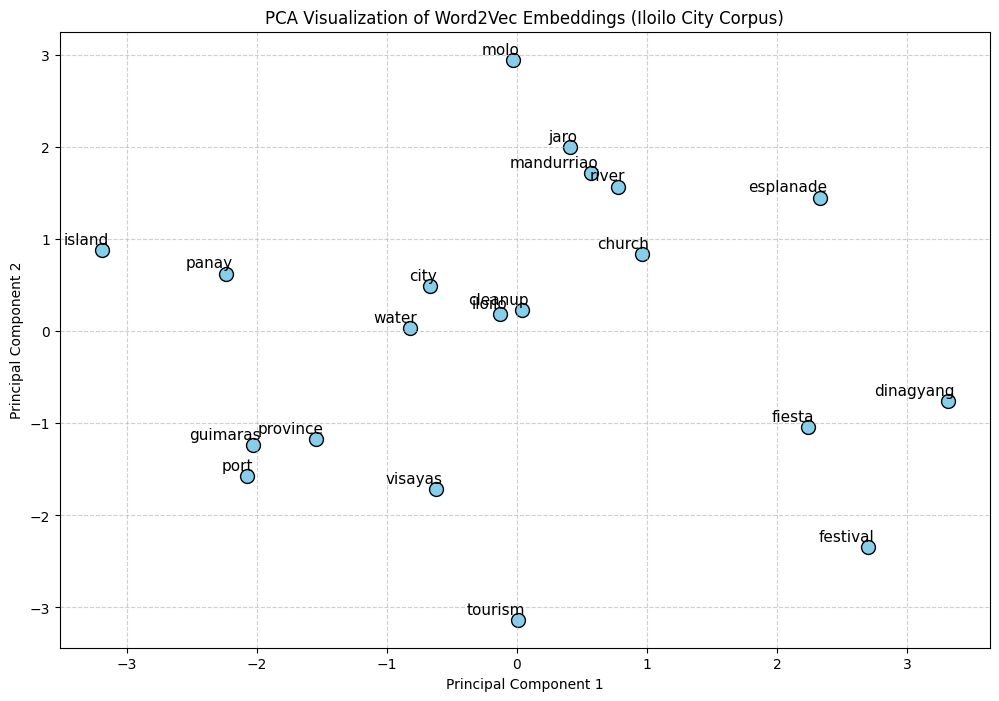

In [110]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_pca(model_path: str):
    model = Word2Vec.load(model_path)
    
    words_to_visualize = [
        "iloilo", "city", "panay", "visayas", "guimaras", "province", 
        "jaro", "molo", "cleanup", "mandurriao", 
        "river", "port", "island", "water", "esplanade", 
        "festival", "dinagyang", "fiesta", "church", "tourism"
    ]
    
    valid_words = [word for word in words_to_visualize if word in model.wv]
    
    if len(valid_words) < 20:
        print(f"Warning: Only found {len(valid_words)} words in the vocabulary.")
    
    word_vectors = np.array([model.wv[word] for word in valid_words])
    
    pca = PCA(n_components=2, random_state=42)
    two_d_vectors = pca.fit_transform(word_vectors)
    
    plt.figure(figsize=(12, 8))
    plt.scatter(two_d_vectors[:, 0], two_d_vectors[:, 1], edgecolors='k', c='skyblue', s=100)
    
    for i, word in enumerate(valid_words):
        plt.annotate(word, 
                     xy=(two_d_vectors[i, 0], two_d_vectors[i, 1]), 
                     xytext=(5, 2), 
                     textcoords='offset points', 
                     ha='right', 
                     va='bottom',
                     fontsize=11)
        
    plt.title("PCA Visualization of Word2Vec Embeddings (Iloilo City Corpus)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.savefig("pca_word_vectors.png", bbox_inches='tight')
    plt.show()

visualize_pca("exercise_5_skipgram_sgns.model")